In [ ]:
# Install required libraries
!pip install shap transformers datasets torch scikit-learn

# Import required libraries
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from datasets import Dataset
from transformers import XLMRobertaTokenizerFast, XLMRobertaForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import torch

# Ensure GPU is used if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Predefined list of German stopwords
german_stopwords = set([
    # Add German stopwords here if needed
])

# Preprocess the text
def preprocess_text(text):
    text = re.sub(r'\S+@\S+\.\S+', '', text)  # Remove emails
    text = re.sub(r'[^A-Za-zäöüß ]+', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = ' '.join([word for word in text.split() if word not in german_stopwords])  # Remove stopwords
    return text

# Load the dataset
dataset = pd.read_csv("gahd_filtered.csv")

# Check label distribution
print("Original Label Distribution:", dataset['label'].value_counts())

# Apply preprocessing
dataset["text"] = dataset["text"].apply(preprocess_text)

# Handle class imbalance
majority_class = dataset[dataset["label"] == 0]
minority_class = dataset[dataset["label"] == 1]

minority_upsampled = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)

balanced_dataset = pd.concat([majority_class, minority_upsampled]).sample(frac=1, random_state=42)

# Check new label distribution
print("Balanced Label Distribution:", balanced_dataset['label'].value_counts())

# Split into training and test sets
train_df, test_df = train_test_split(balanced_dataset, test_size=0.2, random_state=42, stratify=balanced_dataset["label"])
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenizer and model
model_name = "xlm-roberta-base"
tokenizer = XLMRobertaTokenizerFast.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

train_tokenized = train_tokenized.remove_columns(["text", "__index_level_0__"])
test_tokenized = test_tokenized.remove_columns(["text", "__index_level_0__"])

train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized = test_tokenized.rename_column("label", "labels")

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

# Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    }

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    learning_rate=3e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    save_total_limit=2,
)

# Model
model = XLMRobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Train the model
trainer.train()

# Save the model and tokenizer
model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")

# Evaluate the model
eval_results = trainer.evaluate()
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")


Using device: cuda
Original Label Distribution: label
0    6330
1    4666
Name: count, dtype: int64
Balanced Label Distribution: label
0    6330
1    6330
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

Map:   0%|          | 0/10128 [00:00<?, ? examples/s]

Map:   0%|          | 0/2532 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.686800,0.637319,0.656003,0.653265,0.661091,0.656003
2,0.643000,0.562676,0.697472,0.686676,0.729040,0.697472
3,0.592900,0.534848,0.738547,0.727218,0.786070,0.738547
4,0.489000,0.499084,0.767378,0.767304,0.767716,0.767378
5,0.440800,0.475104,0.781991,0.778759,0.799487,0.781991


Accuracy: 0.7820
F1-Score: 0.7788


You are using a model of type xlm-roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./saved_model and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.laye

Sample Texts from Dataset:
Sample 1: wir sind gerade in fahrt also verpassen sie es nicht
Sample 2: gaaaaaaaaays sccccccccum der erde


PartitionExplainer explainer: 3it [00:11,  5.51s/it]


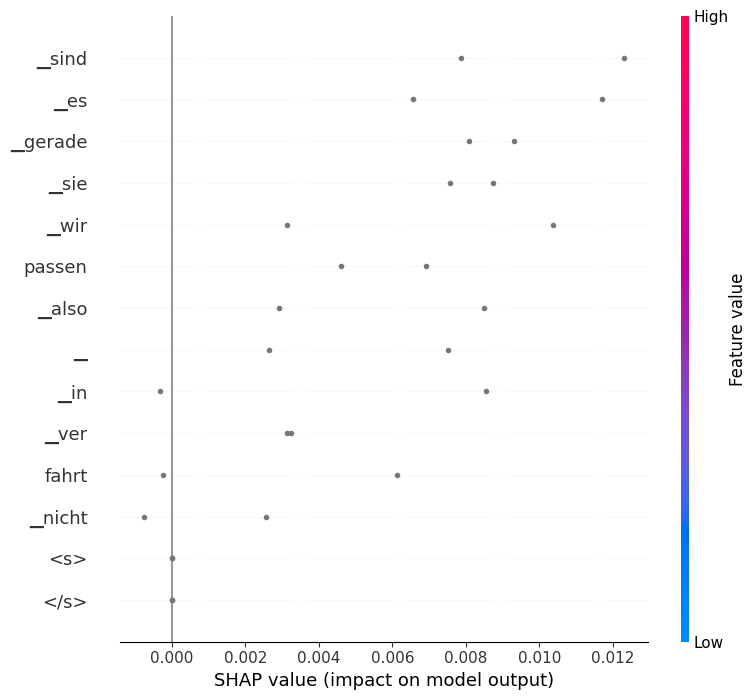


Force Plot for Sample 1: wir sind gerade in fahrt also verpassen sie es nicht


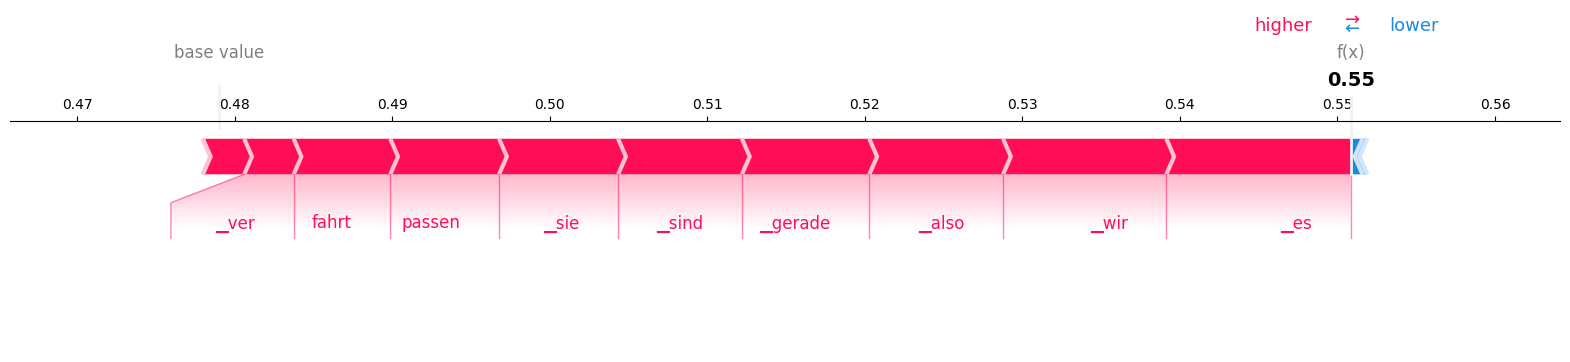


Force Plot for Sample 2: gaaaaaaaaays sccccccccum der erde


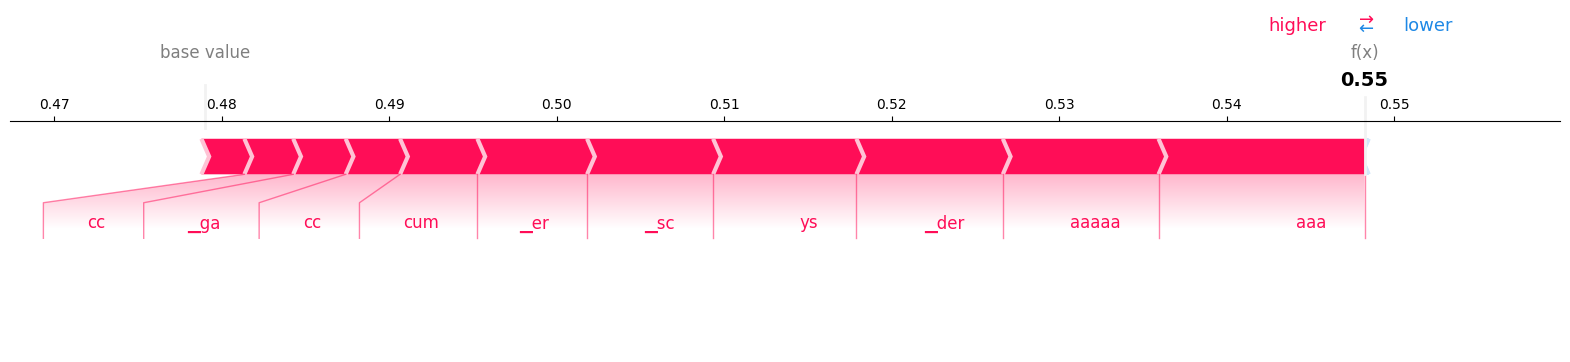


Top 10 Most Important Features (Tokens):
Token: ▁sind, Importance: 0.0101
Token: ▁es, Importance: 0.0091
Token: ▁gerade, Importance: 0.0087
Token: ▁sie, Importance: 0.0081
Token: ▁wir, Importance: 0.0067
Token: passen, Importance: 0.0058
Token: ▁also, Importance: 0.0057
Token: ▁, Importance: 0.0051
Token: ▁in, Importance: 0.0044
Token: ▁ver, Importance: 0.0032

Feature importance saved to 'feature_importance.csv'.


In [ ]:
# Install required libraries
!pip install shap transformers torch

# Import required libraries
import shap
import numpy as np
import csv
from transformers import BertTokenizerFast, BertForSequenceClassification

# Load the trained model and tokenizer
model = BertForSequenceClassification.from_pretrained("./saved_model")
tokenizer = BertTokenizerFast.from_pretrained("./saved_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Define predict_proba for SHAP
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, list) and all(isinstance(t, list) for t in texts):
        texts = [" ".join(tokens) for tokens in texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError(f"Unexpected input format: {type(texts)}")

    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Initialize SHAP Explainer with Text Masker
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)

# Select random sample texts from the test dataset
sample_texts = test_df.sample(2, random_state=42)["text"].tolist()

print("Sample Texts from Dataset:")
for i, text in enumerate(sample_texts, 1):
    print(f"Sample {i}: {text}")

# Compute SHAP values
shap_values = explainer(sample_texts)

# Extract Tokens and Normalize SHAP Values
tokens_list = [
    tokenizer.convert_ids_to_tokens(tokenizer(sample, truncation=True)["input_ids"])
    for sample in sample_texts
]
max_len = max(len(value.values) for value in shap_values)
normalized_shap_values = [
    np.pad(value.values[:, 1], (0, max_len - len(value.values[:, 1])), constant_values=0)
    for value in shap_values
]
normalized_tokens = [
    tokens + ['[PAD]'] * (max_len - len(tokens)) for tokens in tokens_list
]

# SHAP Summary Plot
shap.initjs()
shap.summary_plot(
    shap_values=np.array(normalized_shap_values),
    features=np.array(normalized_tokens),
    feature_names=normalized_tokens[0]
)

# SHAP Force Plot
for i, text in enumerate(sample_texts):
    print(f"\nForce Plot for Sample {i + 1}: {text}")
    shap.force_plot(
        base_value=shap_values[i].base_values[1],
        shap_values=shap_values[i].values[:, 1],
        features=tokens_list[i],
        matplotlib=True
    )

# Calculate Global Feature Importance
# Average absolute SHAP values across all samples
feature_importance = np.mean(np.abs(normalized_shap_values), axis=0)

# Combine feature importance with tokens
feature_importance_data = list(zip(normalized_tokens[0], feature_importance))

# Sort tokens by importance
sorted_feature_importance = sorted(feature_importance_data, key=lambda x: x[1], reverse=True)

# Display Top 10 Most Important Features
print("\nTop 10 Most Important Features (Tokens):")
for token, importance in sorted_feature_importance[:10]:
    print(f"Token: {token}, Importance: {importance:.4f}")

# Save Feature Importance to CSV
with open("feature_importance.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Token", "Importance"])
    writer.writerows(sorted_feature_importance)

print("\nFeature importance saved to 'feature_importance.csv'.")
